# Plot extrapolation results

Minimal plotting notebook for the outputs of `extrapolate.py`.

The figure has 3 rows and 2 columns:

- each row: one dataset and its selected extrapolation axis;
- left column: predicted rho;
- right column: predicted epsilon;
- only PC1 and PC2 are plotted;
- shaded bands show ±1 predicted standard deviation;
- dashed vertical lines show the analytical asymptotic-regime estimates, when available.


In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


In [14]:
# Edit this list if needed.
# Each entry becomes one row of the figure.

DATASETS = [
    {"name": "1 Gallego-Carracedo et al", "axis": "neurons"},
    {"name": "2 Chillale et al", "axis": "trials"},
    {"name": "3 Luo et al", "axis": "animals"},
]

RESULTS_ROOT = Path("cached_results")

PCS_TO_PLOT = [0, 1]

SAVE_FIGURE = True
FIGURE_PATH = RESULTS_ROOT / "fig5.png"


In [15]:
def load_result(dataset_name, axis, root=RESULTS_ROOT):
    folder = root / dataset_name / axis

    if not folder.exists():
        raise FileNotFoundError(f"Missing result folder: {folder}")

    result = {
        "grid": np.load(folder / f"{axis}_grid.npy"),
        "rho": np.load(folder / f"{axis}_mean_rho.npy"),
        "epsilon": np.load(folder / f"{axis}_epsilon.npy"),
        "rho_std": np.load(folder / f"{axis}_mean_rho_std.npy"),
        "epsilon_std": np.load(folder / f"{axis}_epsilon_std.npy"),
    }

    rho_asymp_path = folder / f"{axis}_asymptotic_rho.npy"
    eps_asymp_path = folder / f"{axis}_asymptotic_epsilon.npy"

    result["rho_asymp"] = np.load(rho_asymp_path) if rho_asymp_path.exists() else None
    result["epsilon_asymp"] = np.load(eps_asymp_path) if eps_asymp_path.exists() else None

    return result


def plot_metric_with_bands(ax, x, y, y_std, pcs, ylabel, asymptotic_start=None):
    n_pcs = y.shape[1]

    colors=[(0.8,0,0),(0,0.7,0.7)]

    for pc in pcs:
        if pc >= n_pcs:
            continue

        mean = y[:, pc]
        std = y_std[:, pc]

        line = ax.plot(x, mean, color=colors[pc], marker="o", linewidth=1.8, label=f"PC{pc + 1}")[0]
        ax.fill_between(x, mean - std, mean + std, color=colors[pc], alpha=0.2, linestyle='')

        if False:#asymptotic_start is not None and pc < len(asymptotic_start):
            x_asymp = float(np.asarray(asymptotic_start[pc]).reshape(-1)[0])
            if np.isfinite(x_asymp):
                ax.axvline(
                    x_asymp,
                    linestyle="--",
                    linewidth=1.2,
                    color=line.get_color(),
                    alpha=0.8,
                    label=f"PC{pc + 1} asymp.",
                )

    ax.set_ylabel(ylabel, fontsize=14)


column: 0
eps_asymp: [3.72813914 6.71256259]
column: 1
eps_asymp: [ 9.59006267 12.21374489]
column: 2
eps_asymp: [0.18483177 0.37670758]
Saved figure to: cached_results/fig5.png


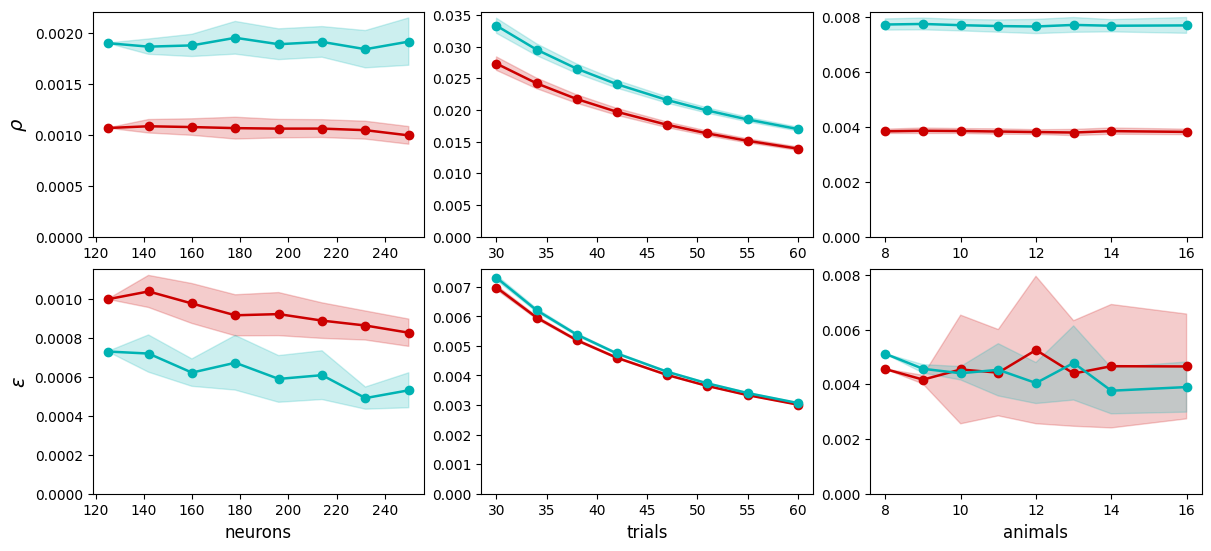

In [16]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(12, 5.4),
    constrained_layout=True,
)

for col, cfg in enumerate(DATASETS):
    dataset_name = cfg["name"]
    axis = cfg["axis"]

    result = load_result(dataset_name, axis)
    x = result["grid"]

    ax_rho = axes[0, col]
    ax_eps = axes[1, col]

    plot_metric_with_bands(
        ax_rho,
        x,
        result["rho"],
        result["rho_std"],
        PCS_TO_PLOT,
        ylabel=r"$\rho$" if col == 0 else "",
        asymptotic_start=result["rho_asymp"],
    )

    print("column:", col)
    print("eps_asymp:", result["epsilon_asymp"])

    plot_metric_with_bands(
        ax_eps,
        x,
        result["epsilon"],
        result["epsilon_std"],
        PCS_TO_PLOT,
        ylabel=r"$\epsilon$" if col == 0 else "",
        asymptotic_start=result["epsilon_asymp"],
    )

    #ax_rho.set_title(f"{axis}", fontsize=11)
    ax_rho.set_xlabel("")
    ax_rho.set_ylim(0,ax_rho.get_ylim()[1])
    ax_eps.set_xlabel(axis, fontsize=12)
    ax_eps.set_ylim(0,ax_eps.get_ylim()[1])

    if False: #col > 0:
        ax_rho.tick_params(labelleft=False)
        ax_eps.tick_params(labelleft=False)

handles, labels = axes[0, 0].get_legend_handles_labels()

#fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=4, frameon=False, fontsize=9)

if SAVE_FIGURE:
    FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_PATH, dpi=300, bbox_inches="tight")
    print(f"Saved figure to: {FIGURE_PATH}")

plt.show()